## Problem 3

We aim to implement PCA on the Optdigits features. We will calculate and plot the reconstruction error E(n) for different values of n.

### Imports and Setup

In [77]:
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo 

In [78]:
optical_recognition_of_handwritten_digits = fetch_ucirepo(id=80) 

# data samples with attributes
X_df = optical_recognition_of_handwritten_digits.data.features 
# data samples with digit outcomes
y_df = optical_recognition_of_handwritten_digits.data.targets 

In [79]:
print(X_df)

      Attribute1  Attribute2  Attribute3  Attribute4  Attribute5  Attribute6  \
0              0           1           6          15          12           1   
1              0           0          10          16           6           0   
2              0           0           8          15          16          13   
3              0           0           0           3          11          16   
4              0           0           5          14           4           0   
...          ...         ...         ...         ...         ...         ...   
5615           0           0           4          10          13           6   
5616           0           0           6          16          13          11   
5617           0           0           1          11          15           1   
5618           0           0           2          10           7           0   
5619           0           0          10          14           8           1   

      Attribute7  Attribute8  Attribute

In [80]:
def calculate_error_for_n(X_original, X_normalized, eigenvectors_sorted, mu, n):
    """
    Project a corresponding matrix using the top n eigenvectors, 
    then reconstructing the data matrix and returning the total squared reconstruction error E(n).
    """
    W = eigenvectors_sorted[:, :n]
    
    z = np.dot(X_normalized, W)
    X_reconstructed = np.dot(z, W.T) + mu
    
    return np.sum((X_reconstructed - X_original) ** 2)

#### 1. Standardize data. For each feature, subtract the mean to normalize every feature

In [81]:
# Probably fine here since the column names aren't super meaningful
X = X_df.to_numpy()

mu = np.mean(X, axis=0)
X_normalized = X - mu
print(X_normalized)

[[ 0.          0.69786477  0.60676157 ... -5.72081851 -2.09359431
  -0.25409253]
 [ 0.         -0.30213523  4.60676157 ... -3.72081851 -2.09359431
  -0.25409253]
 [ 0.         -0.30213523  2.60676157 ... -6.72081851 -2.09359431
  -0.25409253]
 ...
 [ 0.         -0.30213523 -4.39323843 ... -0.72081851 -2.09359431
  -0.25409253]
 [ 0.         -0.30213523 -3.39323843 ...  5.27918149 -2.09359431
  -0.25409253]
 [ 0.         -0.30213523  4.60676157 ...  5.27918149 -1.09359431
  -0.25409253]]


#### 2. Compute covariance matrix

In [82]:
# rowvar=False since our variables here are as columns
cov_matrix = np.cov(X_normalized, rowvar=False)
print(cov_matrix)

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  7.74332511e-01  2.26095055e+00 ... -4.44026020e-03
   2.79066892e-01 -2.57072629e-02]
 [ 0.00000000e+00  2.26095055e+00  2.18343020e+01 ... -5.11124559e-01
   2.20985168e+00  5.89153856e-01]
 ...
 [ 0.00000000e+00 -4.44026020e-03 -5.11124559e-01 ...  3.38207803e+01
   1.53932816e+01  1.91255938e+00]
 [ 0.00000000e+00  2.79066892e-01  2.20985168e+00 ...  1.53932816e+01
   1.63859707e+01  3.18425829e+00]
 [ 0.00000000e+00 -2.57072629e-02  5.89153856e-01 ...  1.91255938e+00
   3.18425829e+00  2.01230751e+00]]


#### 3. Calculate eigenvectors and eigenvalues

In [83]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print(f"{eigenvalues=}")
print(f"{eigenvectors=}")

eigenvalues=array([-6.22886846e-16,  0.00000000e+00,  2.98312290e-04,  5.72189189e-04,
        8.87923901e-04,  2.75175268e-03,  7.44567946e-03,  1.10002715e-02,
        3.47715399e-02,  3.81505725e-02,  7.16936542e-02,  8.78548949e-02,
        1.11537889e-01,  2.52426277e-01,  3.63231316e-01,  6.94936291e-01,
        1.02272341e+00,  1.12517899e+00,  1.29680143e+00,  1.52564432e+00,
        1.64634794e+00,  1.86508406e+00,  2.10933808e+00,  2.36055791e+00,
        2.71568719e+00,  2.83712636e+00,  3.05271910e+00,  3.22170475e+00,
        3.74311409e+00,  3.90832053e+00,  4.05076234e+00,  4.16040472e+00,
        4.42510687e+00,  4.76370665e+00,  5.02733765e+00,  5.60757064e+00,
        6.18850037e+00,  6.84919027e+00,  7.49751406e+00,  8.08916293e+00,
        8.67301833e+00,  8.97442904e+00,  1.00847225e+01,  1.08411325e+01,
        1.15136921e+01,  1.18809568e+01,  1.48275230e+01,  1.55500771e+01,
        1.70914129e+01,  1.74511821e+01,  1.97810281e+01,  2.26110206e+01,
        2.678

#### 4. Sort and select top n relevant components to form the projection matrix

In [84]:
# idx to use to sort both eigenvalues and eigenvectors
sorted_eigenvalues_idx = np.argsort(eigenvalues)[::-1]
print(f"{sorted_eigenvalues_idx=}")

eigenvalues_sorted = eigenvalues[sorted_eigenvalues_idx]
eigenvectors_sorted = eigenvectors[:, sorted_eigenvalues_idx]
print(f"{eigenvalues_sorted=}")
print(f"{eigenvectors_sorted=}")

sorted_eigenvalues_idx=array([63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47,
       46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30,
       29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13,
       12, 11, 10,  9,  8,  7,  6,  5,  4,  3,  2,  1,  0])
eigenvalues_sorted=array([ 1.74756983e+02,  1.62755865e+02,  1.43486999e+02,  9.98127372e+01,
        6.83457052e+01,  6.09993542e+01,  5.46623120e+01,  4.34085063e+01,
        4.20651534e+01,  3.80327752e+01,  2.89219451e+01,  2.67809783e+01,
        2.26110206e+01,  1.97810281e+01,  1.74511821e+01,  1.70914129e+01,
        1.55500771e+01,  1.48275230e+01,  1.18809568e+01,  1.15136921e+01,
        1.08411325e+01,  1.00847225e+01,  8.97442904e+00,  8.67301833e+00,
        8.08916293e+00,  7.49751406e+00,  6.84919027e+00,  6.18850037e+00,
        5.60757064e+00,  5.02733765e+00,  4.76370665e+00,  4.42510687e+00,
        4.16040472e+00,  4.05076234e+00,  3.90832053e+00,  3.74311409e+00

#### For each n:
#### 5. Project the centered data into the lower-dimensional space, giving us final principal component scores
#### 6. Reconstruct the data by back-projecting into original dimension of space
#### 7. Take the errors accordingly

In [85]:
# For completeness, we might as well try for all possible values of n

errors = [calculate_error_for_n(X, X_normalized, eigenvectors_sorted, mu, n) for n in range(1, X.shape[1])]
print(errors)

[np.float64(5783747.334236046), np.float64(4869222.128146577), np.float64(4062968.680986221), np.float64(3502120.9105235594), np.float64(3118086.3928449065), np.float64(2775331.0217807805), np.float64(2468183.490612908), np.float64(2224271.0937542296), np.float64(1987906.9965756703), np.float64(1774200.8326709068), np.float64(1611688.4232351265), np.float64(1461206.106327335), np.float64(1334154.7816293102), np.float64(1223005.1849574929), np.float64(1124946.9930137245), np.float64(1028910.3437203292), np.float64(941534.4605498693), np.float64(858218.6086356044), np.float64(791459.5122557592), np.float64(726764.0760789524), np.float64(665847.7526532887), np.float64(609181.6970707607), np.float64(558754.3802766944), np.float64(510020.6902682372), np.float64(464567.6837722458), np.float64(422439.1522470105), np.float64(383953.55212719995), np.float64(349180.3685351107), np.float64(317671.42913317506), np.float64(289422.8188987322), np.float64(262655.5512103491), np.float64(237790.8756973

#### 7. Plot errors accordingly

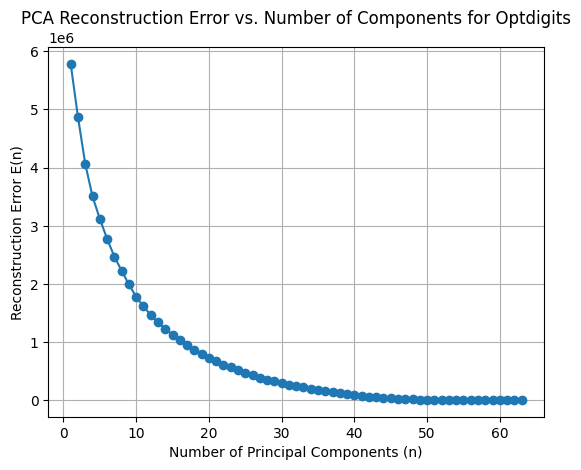

In [86]:
plt.plot(range(1, X.shape[1]), errors, "-o")
plt.xlabel("Number of Principal Components (n)")
plt.ylabel("Reconstruction Error E(n)")
plt.title("PCA Reconstruction Error vs. Number of Components for Optdigits")
plt.grid(True)
plt.savefig("3_graph.png")
plt.show()